# Department Co-purchases with Produce

The merchandising analytics team wants to understand how frequently different product departments are purchased together with Produce.

## Load and prepare the data

Load the prior purchase history and map each purchased product to its department.

In [6]:
import matplotlib.pyplot as plt
import pandas as pd


DATA_DIR = "../../data/shop"

order_products = pd.read_csv(
    f"{DATA_DIR}/order_products__prior.csv",
    usecols=["order_id", "product_id"],
)

products = pd.read_csv(
    f"{DATA_DIR}/products.csv",
    usecols=["product_id", "department_id"],
)

departments = pd.read_csv(
    f"{DATA_DIR}/departments.csv",
)

order_products = order_products.merge(
    products,
    on="product_id",
    how="left",
)


order_products.head()

,order_id,product_id,department_id
0,2,33120,16
1,2,28985,4
2,2,9327,13
3,2,45918,13
4,2,30035,13


## Identify Produce orders

Identify all orders containing at least one Produce product. These orders define the baskets used for the co-purchase comparison.

In [7]:
produce_id = departments.loc[
    departments["department"].eq("produce"),
    "department_id",
].iloc[0]

produce_orders = order_products.loc[
    order_products["department_id"].eq(produce_id),
    "order_id",
].unique()


print(
    "Produce orders:",
    f"{len(produce_orders):,}",
)

Produce orders: 2,409,320


## Prepare basket-level department records

A department should contribute at most once to the co-purchase count for a given order. Convert the Produce-order purchases into unique order–department pairs before counting co-purchases.

In [8]:
basket_departments = (
    order_products[
        order_products["order_id"].isin(produce_orders)
        & order_products["department_id"].ne(produce_id)
    ]
    [["order_id", "department_id"]]
    .drop_duplicates()
)


print(
    "Unique order-department pairs:",
    f"{len(basket_departments):,}",
)

print(
    "Departments represented:",
    basket_departments["department_id"].nunique(),
)

Unique order-department pairs: 10,331,977
Departments represented: 20


## Calculate basket-level co-purchase counts

Count the number of Produce orders containing each other department and rank departments by basket-level co-purchase frequency.

In [9]:
copurchase_counts = (
    basket_departments["department_id"]
    .value_counts()
    .rename_axis("department_id")
    .reset_index(name="copurchase_count")
    .merge(
        departments,
        on="department_id",
        how="left",
    )
    [["department", "copurchase_count"]]
)


print(
    "Top departments purchased with Produce:"
)

print(
    copurchase_counts
    .head(15)
    .to_string(index=False)
)

Top departments purchased with Produce:
     department  copurchase_count
     dairy eggs           1769735
         snacks           1084254
      beverages           1072365
         frozen            958413
         pantry            922477
         bakery            736103
           deli            662454
   canned goods            598951
dry goods pasta            519983
   meat seafood            503048
      breakfast            423872
      household            327133
  personal care            226070
  international            192694
         babies            148171


## Visualize department co-purchases

Compare the leading departments by the number of Produce baskets in which they appear.

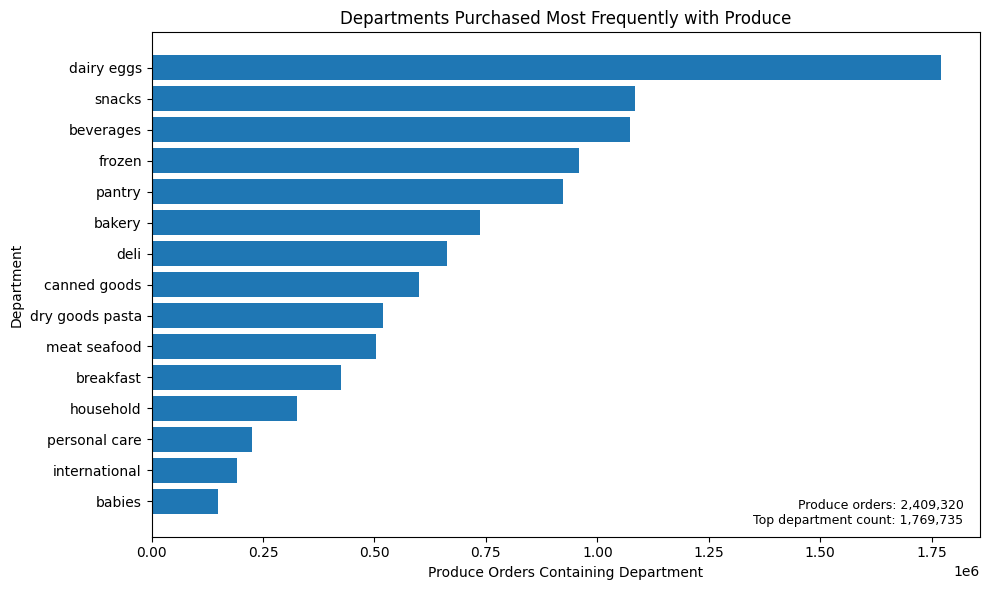

In [10]:
top_departments = (
    copurchase_counts
    .head(15)
    .sort_values(
        "copurchase_count",
        ascending=True,
    )
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.barh(
    top_departments["department"],
    top_departments["copurchase_count"],
)

ax.set_title(
    "Departments Purchased Most Frequently "
    "with Produce"
)

ax.set_xlabel(
    "Produce Orders Containing Department"
)

ax.set_ylabel(
    "Department"
)

ax.text(
    0.98,
    0.02,
    (
        f"Produce orders: {len(produce_orders):,}\n"
        f"Top department count: "
        f"{copurchase_counts['copurchase_count'].max():,}"
    ),
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
)

plt.tight_layout()
plt.show()

## Conclusion

Dairy & Eggs has the highest basket-level co-purchase count with Produce.

The comparison counts each department at most once within an order, so departments with multiple purchased items in the same basket do not receive additional co-purchase counts from that order.